# Regression Algorithms

## What is Regression?
Regression helps us **predict numbers** (like house prices, temperatures, or salaries).

### Today we'll learn:
1. **Linear Regression** - Draw a straight line
2. **Polynomial Regression** - Draw a curved line
3. **Ridge Regression** - Linear regression with penalty
4. **Lasso Regression** - Can ignore useless features
5. **Decision Tree** - Makes decisions like a flowchart
6. **Random Forest** - Many decision trees working together

## Step 1: Import Libraries 📚

In [1]:
# For working with data
import pandas as pd
import numpy as np

# For making charts
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

## Step 2: Load the Data 📊

We'll use **California Housing** dataset to predict house prices.

In [2]:
# Load data
data = pd.read_csv('/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv')

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Features

- **longitude**: The longitudinal coordinate of the house location. 

- **latitude**: The latitudinal coordinate of the house location.  

- **housing_median_age**: The median age of houses in a given block. Higher values indicate older neighborhoods

- **total_rooms**: Total number of rooms in all houses within a block.

- **total_bedrooms**: Total number of bedrooms in all houses within a block.

- **population**: Total number of people living in a block.

- **households**: Total number of households (groups of people living together) in a block.

- **median_income**: Median income of households in the block (measured in tens of thousands of USD).  
  Example: 3 = $30,000

- **median_house_value**: Median house price in the block (target variable). This is what we usually try to predict.

- **ocean_proximity**: Categorical variable describing the location relative to the ocean.  
  Possible values:
  - `<1H OCEAN` : Less than 1 hour from the ocean  
  - `INLAND` : Inland area  
  - `NEAR OCEAN` : Close to the ocean  
  - `NEAR BAY` : Close to San Francisco Bay  
  - `ISLAND` : Located on an island

## Notes

- Each row represents a **block group** (not a single house).
- The goal is usually to predict **median_house_value** using the other features.

```

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Step 3: Clean the Data 🧹

In [5]:
# Remove rows with missing values
data = data.dropna()

# Remove text column
#data = data.drop('ocean_proximity', axis=1)

# Encode the categorical column
encoder = LabelEncoder()
data['ocean_proximity'] = encoder.fit_transform(data['ocean_proximity'])

print("✅ Data cleaned!")
print("New size:", data.shape)

✅ Data cleaned!
New size: (20433, 10)


/tmp/ipykernel_775/3176471501.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ocean_proximity'] = encoder.fit_transform(data['ocean_proximity'])


In [6]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


## Step 4: Prepare Data for Training 🎯

**X** = Features (information we use to predict)  
**y** = Target (what we want to predict - house price)

In [7]:
# Separate features (X) and target (y)
X = data.drop('median_house_value', axis=1)  # All columns except price
y = data['median_house_value']  # Only the price

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16346, 9)
Testing data: (4087, 9)


## Step 5: Try Different Models! 🚀

### Model 1: Linear Regression
**Simple straight line prediction**

In [8]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

LinearRegression()

In [9]:
model_linear.predict(X_test)

array([195854.43379088, 157564.34984099, 202476.8302992 , ...,
       131125.61673621, 155283.141129  , 165053.13670181])

In [10]:
# Create and train the model
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

# Make predictions
predictions = model_linear.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("📊 Linear Regression Results:")
print(f"Average Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f} (closer to 1 is better)")
print(f"MSE : {mse:.3f}")

📊 Linear Regression Results:
Average Error: $51,389
R² Score: 0.640 (closer to 1 is better)
MSE : 4924108937.912


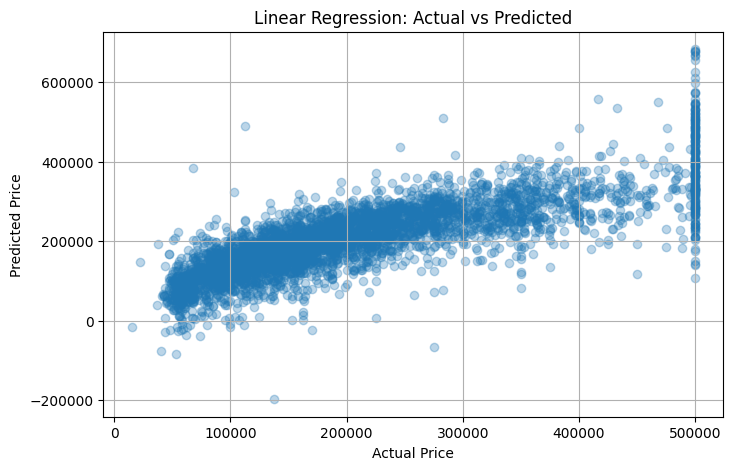

In [11]:
# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid()
plt.show()

### Model 2: Polynomial Regression
**Can draw curves, not just straight lines**

In [13]:
# Transform data to include squared terms
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

# Create and train the model
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# Make predictions
predictions = model_poly.predict(X_test_poly)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("📊 Polynomial Regression Results:")
print(f"Average Error: {mae:,.0f}")
print(f"R² Score: {r2:.3f}")
print(f"MSE Error: {mse:,.0f}")

📊 Polynomial Regression Results:
Average Error: 43,422
R² Score: 0.706
MSE Error: 4,015,887,271


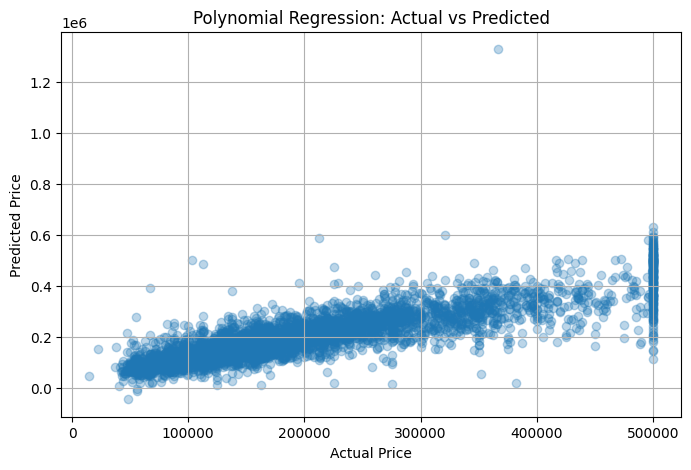

In [14]:
# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Polynomial Regression: Actual vs Predicted')
plt.grid()
plt.show()

### Model 3: Ridge Regression
**Linear regression that prevents overfitting**

In [15]:
# Create and train the model
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

# Make predictions
predictions = model_ridge.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("📊 Ridge Regression Results:")
print(f"Average Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f}")
print(f"Average Error: ${mse:,.0f}")

📊 Ridge Regression Results:
Average Error: $51,389
R² Score: 0.640
Average Error: $4,924,110,268


### Model 4: Lasso Regression
**Can automatically ignore useless features**

In [16]:
# Create and train the model
model_lasso = Lasso(alpha=100)
model_lasso.fit(X_train, y_train)

# Make predictions
predictions = model_lasso.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("📊 Lasso Regression Results:")
print(f"Average Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f}")

# Show which features were kept
print("\n📌 Feature Importance:")
for feature, coef in zip(X.columns, model_lasso.coef_):
    print(f"  {feature}: {coef:.2f}")

📊 Lasso Regression Results:
Average Error: $51,383
R² Score: 0.640

📌 Feature Importance:
  longitude: -42339.12
  latitude: -42097.62
  housing_median_age: 1161.65
  total_rooms: -8.42
  total_bedrooms: 115.41
  population: -36.86
  households: 42.34
  median_income: 40285.50
  ocean_proximity: -288.17


### Model 5: Decision Tree
**Makes decisions like a flowchart**

In [17]:
# Create and train the model
model_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
model_tree.fit(X_train, y_train)

# Make predictions
predictions = model_tree.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("📊 Decision Tree Results:")
print(f"Average Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f}")

# Show most important features
print("\n📌 Most Important Features:")
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_tree.feature_importances_
})
print(importances)

📊 Decision Tree Results:
Average Error: $40,114
R² Score: 0.723

📌 Most Important Features:
              Feature  Importance
0           longitude    0.099360
1            latitude    0.109917
2  housing_median_age    0.036796
3         total_rooms    0.007271
4      total_bedrooms    0.011003
5          population    0.012575
6          households    0.007885
7       median_income    0.579389
8     ocean_proximity    0.135804


In [ ]:
# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Decision Tree Regression: Actual vs Predicted')
plt.grid()
plt.show()

### Model 6: Random Forest
**Many decision trees voting together - Usually the best!**

In [18]:
# Create and train the model
model_forest = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
model_forest.fit(X_train, y_train)

# Make predictions
predictions = model_forest.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("📊 Random Forest Results:")
print(f"Average Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f}")

📊 Random Forest Results:
Average Error: $32,234
R² Score: 0.820


In [ ]:
# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

## 🎯 Summary

1. **Linear Regression**: Simple and fast, draws a straight line
2. **Polynomial Regression**: Can capture curves in data
3. **Ridge Regression**: Like linear but prevents overfitting
4. **Lasso Regression**: Can ignore useless features automatically
5. **Decision Tree**: Makes decisions step by step
6. **Random Forest**: Usually the most accurate!

### Key Metrics:
- **Average Error**: How far off our predictions are (lower = better)
- **R² Score**: How well the model fits (0 to 1, closer to 1 = better)

### When to use what?
- Start with **Linear Regression** (simple baseline)
- Use **Ridge/Lasso** if you have many features
- Use **Random Forest** when you want the best accuracy

---